🔍 Skanowanie folderu 'experiments'...
🔍 Skanowanie folderu 'experiments_finetuning'...
🔍 Skanowanie folderu 'experiments_multitask_naive'...
🔗 Łączenie danych z eksperymentów do zapisu CSV...
📊 Znaleziono eksperymentów: Raw=30, FT=30, Naive=20
💾 Pomyślnie zapisano wyniki eksperymentów do pliku: summary_results_all.csv


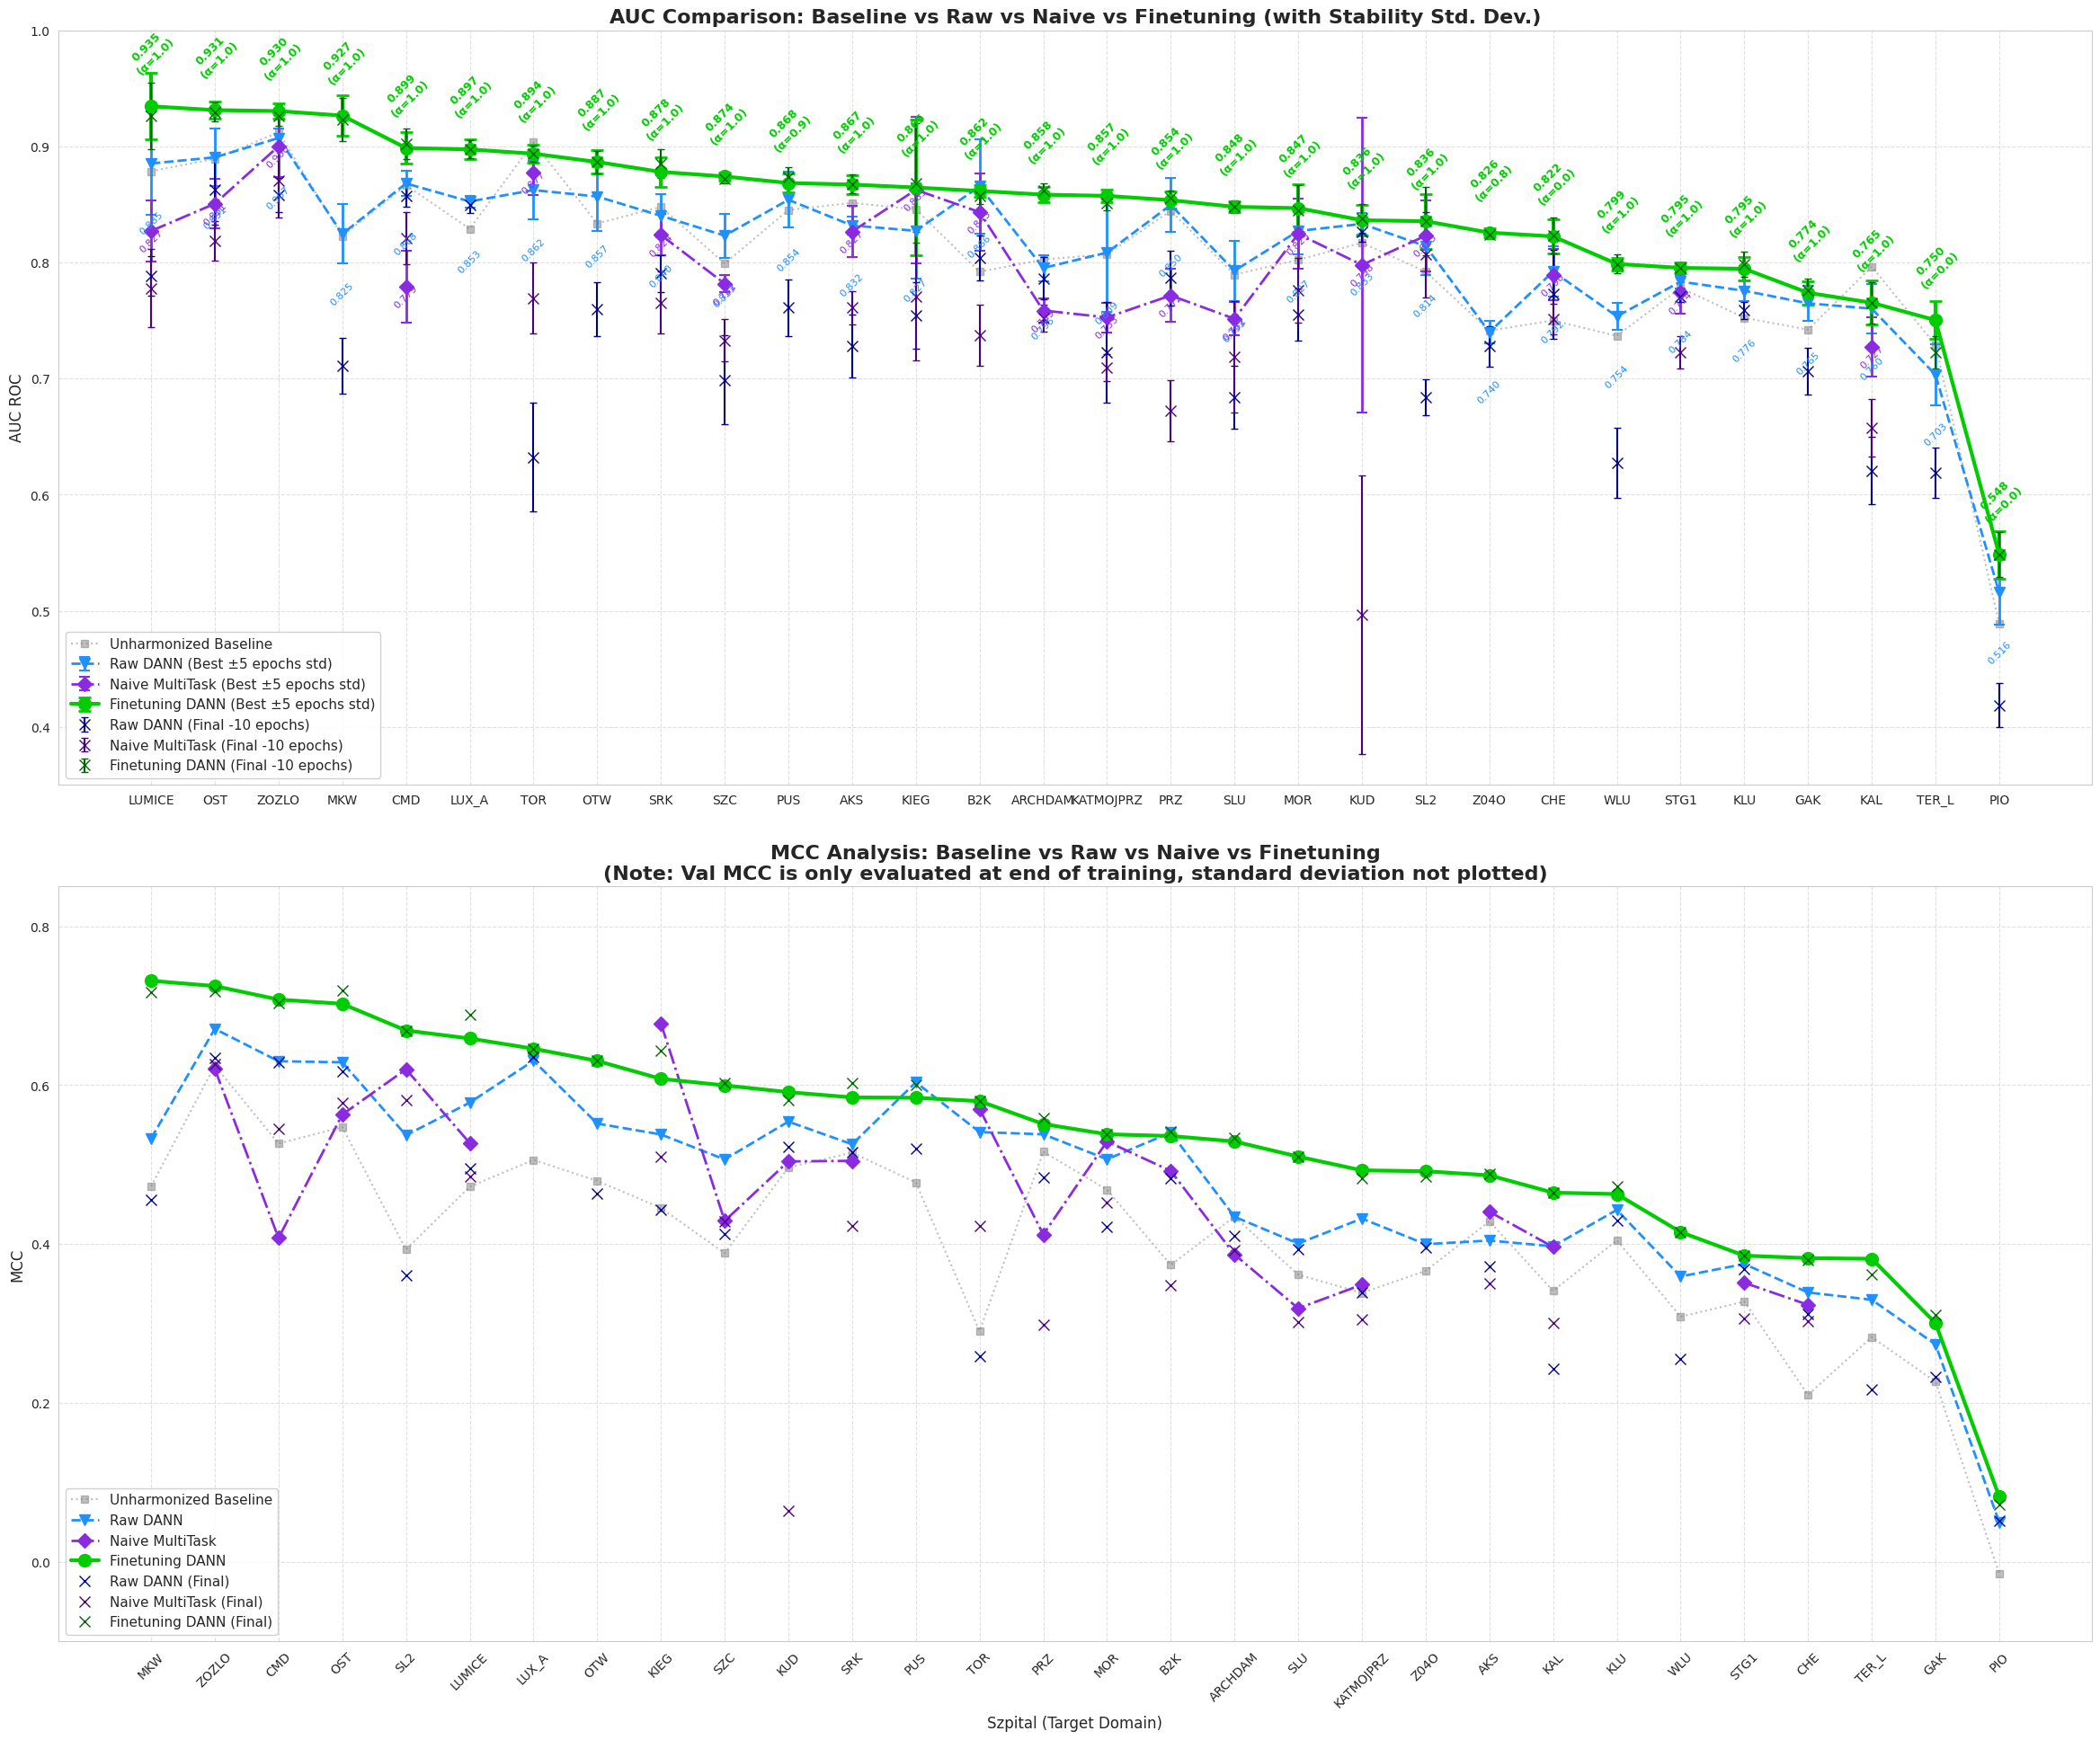

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. FUNKCJA SKANUJĄCA FOLDERY
# ==========================================
def scan_experiments_folder(root_folder, suffix_key):
    """
    Skanuje folder i zwraca DataFrame z kolumnami zakończonymi suffixem (np. _Raw, _FT, _Naive).
    Dodatkowo liczy odchylenie standardowe AUC (Best +- 5 epok, Final - 10 epok).
    """
    data_list = []
    print(f"🔍 Skanowanie folderu '{root_folder}'...")

    if not os.path.exists(root_folder):
        print(f"⚠️ Folder {root_folder} nie istnieje!")
        return pd.DataFrame()

    for folder_name in os.listdir(root_folder):
        folder_path = os.path.join(root_folder, folder_name)
        
        if os.path.isdir(folder_path):
            csv_path = os.path.join(folder_path, "final_results.csv")
            log_path = os.path.join(folder_path, "training_log.csv")
            
            if os.path.exists(csv_path):
                try:
                    # Fix nazw szpitali
                    if folder_name.startswith("LUX_A"): hospital_code = "LUX_A"
                    elif folder_name.startswith("TER_L"): hospital_code = "TER_L"
                    else: hospital_code = folder_name.split('_')[0]
                    
                    res_df = pd.read_csv(csv_path)
                    
                    def get_val(df, metric):
                        row = df[df['Metric_Name'] == metric]
                        return float(row['Value'].values[0]) if not row.empty else None

                    auc_best = get_val(res_df, "Best_Target_Diagnosis_AUC")
                    if auc_best is None: 
                        auc_best = get_val(res_df, "BestTarget_Diagnosis_AUC") 

                    mcc_best = get_val(res_df, "Best_Target_Diagnosis_MCC")
                    auc_final = get_val(res_df, "Final_Target_Diagnosis_AUC")
                    mcc_final = get_val(res_df, "Final_Target_Diagnosis_MCC")
                    
                    # Pobieranie Alpha i liczenie Odchylenia Standardowego z logów
                    alpha_best_val = 0.0
                    std_best = 0.0
                    std_final = 0.0
                    
                    if os.path.exists(log_path):
                        try:
                            log_df = pd.read_csv(log_path)
                            if not log_df.empty and 'Val_Target_AUC' in log_df.columns:
                                best_idx = log_df['Val_Target_AUC'].idxmax()
                                alpha_best_val = log_df.loc[best_idx, 'Alpha']
                                
                                # Std dla Best (okno: best - 5 do best + 5)
                                start_best = max(0, best_idx - 5)
                                end_best = min(len(log_df), best_idx + 6)
                                window_best = log_df['Val_Target_AUC'].iloc[start_best:end_best]
                                std_best = window_best.std() if len(window_best) > 1 else 0.0
                                
                                # Std dla Final (okno: final - 10 do final)
                                final_idx = len(log_df) - 1
                                start_final = max(0, final_idx - 10)
                                end_final = final_idx + 1
                                window_final = log_df['Val_Target_AUC'].iloc[start_final:end_final]
                                std_final = window_final.std() if len(window_final) > 1 else 0.0
                        except Exception as e: 
                            print(f"Błąd analizy logów w {folder_name}: {e}")

                    # Wypełnienie ew. NaN wartością 0
                    if pd.isna(std_best): std_best = 0.0
                    if pd.isna(std_final): std_final = 0.0

                    if auc_best is not None:
                        data_list.append({
                            "Szpital": hospital_code,
                            f"AUC_Best_{suffix_key}": auc_best,
                            f"AUC_Best_{suffix_key}_std": std_best,
                            f"MCC_Best_{suffix_key}": mcc_best,
                            f"AUC_Final_{suffix_key}": auc_final,
                            f"AUC_Final_{suffix_key}_std": std_final,
                            f"MCC_Final_{suffix_key}": mcc_final,
                            f"Alpha_Best_{suffix_key}": alpha_best_val,
                            "Timestamp": folder_name.split('_', 1)[1] if '_' in folder_name else "0"
                        })
                except Exception as e:
                    print(f"   ⚠️ Błąd w {folder_name}: {e}")

    if data_list:
        df = pd.DataFrame(data_list)
        df = df.sort_values('Timestamp').drop_duplicates('Szpital', keep='last')
        return df.drop(columns=['Timestamp'])
    else:
        return pd.DataFrame()

# ==========================================
# 2. POBIERANIE I ŁĄCZENIE DANYCH (ZAPIS)
# ==========================================

df_raw = scan_experiments_folder("experiments", "Raw")
df_ft = scan_experiments_folder("experiments_finetuning", "FT")
df_naive = scan_experiments_folder("experiments_multitask_naive", "Naive")

print("🔗 Łączenie danych z eksperymentów do zapisu CSV...")
dfs_to_merge = [df for df in [df_raw, df_ft, df_naive] if not df.empty]

if dfs_to_merge:
    df_save = dfs_to_merge[0]
    for df in dfs_to_merge[1:]:
        df_save = pd.merge(df_save, df, on="Szpital", how="outer")
else:
    df_save = pd.DataFrame(columns=["Szpital"])

print(f"📊 Znaleziono eksperymentów: Raw={len(df_raw)}, FT={len(df_ft)}, Naive={len(df_naive)}")

# Zapis
if not df_save.empty:
    output_csv = "summary_results_all.csv"
    df_save.to_csv(output_csv, index=False)
    print(f"💾 Pomyślnie zapisano wyniki eksperymentów do pliku: {output_csv}")

# ==========================================
# 3. ŁĄCZENIE Z UNHARMONIZED (DO WYKRESÓW)
# ==========================================
unharmonized_data = [
    {"Szpital": "AKS", "AUC_UH": 0.8514, "MCC_UH": 0.4286}, {"Szpital": "ARCHDAM", "AUC_UH": 0.8026, "MCC_UH": 0.4345},
    {"Szpital": "B2K", "AUC_UH": 0.7920, "MCC_UH": 0.3737}, {"Szpital": "CHE", "AUC_UH": 0.7501, "MCC_UH": 0.2103},
    {"Szpital": "CMD", "AUC_UH": 0.8666, "MCC_UH": 0.5265}, {"Szpital": "GAK", "AUC_UH": 0.7422, "MCC_UH": 0.2268},
    {"Szpital": "KAL", "AUC_UH": 0.7964, "MCC_UH": 0.3411}, {"Szpital": "KATMOJPRZ", "AUC_UH": 0.8071, "MCC_UH": 0.3386},
    {"Szpital": "KIEG", "AUC_UH": 0.8458, "MCC_UH": 0.4455}, {"Szpital": "KLU", "AUC_UH": 0.7524, "MCC_UH": 0.4048},
    {"Szpital": "KUD", "AUC_UH": 0.8170, "MCC_UH": 0.4965}, {"Szpital": "LUMICE", "AUC_UH": 0.8786, "MCC_UH": 0.4722},
    {"Szpital": "LUX_A", "AUC_UH": 0.8290, "MCC_UH": 0.5060}, {"Szpital": "MKW", "AUC_UH": 0.8227, "MCC_UH": 0.4726},
    {"Szpital": "MOR", "AUC_UH": 0.8023, "MCC_UH": 0.4685}, {"Szpital": "OST", "AUC_UH": 0.8893, "MCC_UH": 0.5472},
    {"Szpital": "OTW", "AUC_UH": 0.8336, "MCC_UH": 0.4796}, {"Szpital": "PIO", "AUC_UH": 0.4889, "MCC_UH": -0.0145},
    {"Szpital": "PRZ", "AUC_UH": 0.8445, "MCC_UH": 0.5163}, {"Szpital": "PUS", "AUC_UH": 0.8452, "MCC_UH": 0.4775},
    {"Szpital": "SL2", "AUC_UH": 0.7921, "MCC_UH": 0.3931}, {"Szpital": "SLU", "AUC_UH": 0.7896, "MCC_UH": 0.3615},
    {"Szpital": "SRK", "AUC_UH": 0.8479, "MCC_UH": 0.5151}, {"Szpital": "STG1", "AUC_UH": 0.7783, "MCC_UH": 0.3276},
    {"Szpital": "SZC", "AUC_UH": 0.7991, "MCC_UH": 0.3885}, {"Szpital": "TER_L", "AUC_UH": 0.7290, "MCC_UH": 0.2830},
    {"Szpital": "TOR", "AUC_UH": 0.9034, "MCC_UH": 0.2905}, {"Szpital": "WLU", "AUC_UH": 0.7368, "MCC_UH": 0.3087},
    {"Szpital": "Z04O", "AUC_UH": 0.7413, "MCC_UH": 0.3663}, {"Szpital": "ZOZLO", "AUC_UH": 0.9121, "MCC_UH": 0.6247}
]
df_uh = pd.DataFrame(unharmonized_data)

if not df_save.empty:
    df_plot = pd.merge(df_save, df_uh, on="Szpital", how="outer")
else:
    df_plot = df_uh.copy()

sort_col = "AUC_Best_FT"
if sort_col not in df_plot.columns and "AUC_Best_Raw" in df_plot.columns: 
    sort_col = "AUC_Best_Raw"
elif sort_col not in df_plot.columns and "AUC_Best_Naive" in df_plot.columns:
    sort_col = "AUC_Best_Naive"

if sort_col in df_plot.columns:
    df_auc = df_plot.sort_values(by=sort_col, ascending=False).copy()
    df_mcc = df_plot.sort_values(by=sort_col.replace("AUC", "MCC"), ascending=False).copy()
else:
    df_auc = df_plot.copy()
    df_mcc = df_plot.copy()

# ==========================================
# 4. RYSOWANIE WYKRESÓW
# ==========================================
sns.set_style("whitegrid")
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(24, 20))

col_ft_best = '#00CC00'   
col_ft_final = '#006400'  
col_raw_best = '#1E90FF'  
col_raw_final = '#00008B' 
col_naive_best = '#8A2BE2' 
col_naive_final = '#4B0082' 
col_uh = '#808080'

# -----------------------------------------------------------------------------
# WYKRES 1: AUC ROC (Z Odchyleniem Standardowym)
# -----------------------------------------------------------------------------

# 1. Unharmonized
if "AUC_UH" in df_auc.columns:
    ax1.plot(df_auc["Szpital"], df_auc["AUC_UH"], marker='s', color=col_uh, 
             linewidth=1.5, linestyle=':', markersize=6, alpha=0.5, label='Unharmonized Baseline')

# 2. RAW - Best (Z errorbar)
if "AUC_Best_Raw" in df_auc.columns:
    ax1.errorbar(df_auc["Szpital"], df_auc["AUC_Best_Raw"], 
                 yerr=df_auc["AUC_Best_Raw_std"].fillna(0),
                 marker='v', color=col_raw_best, linewidth=2, linestyle='--', 
                 markersize=8, capsize=4, capthick=1.5, label='Raw DANN (Best ±5 epochs std)')

# 3. NAIVE - Best (Z errorbar)
if "AUC_Best_Naive" in df_auc.columns:
    ax1.errorbar(df_auc["Szpital"], df_auc["AUC_Best_Naive"], 
                 yerr=df_auc["AUC_Best_Naive_std"].fillna(0),
                 marker='D', color=col_naive_best, linewidth=2, linestyle='-.', 
                 markersize=8, capsize=4, capthick=1.5, label='Naive MultiTask (Best ±5 epochs std)')

# 4. FINETUNING - Best (Z errorbar)
if "AUC_Best_FT" in df_auc.columns:
    ax1.errorbar(df_auc["Szpital"], df_auc["AUC_Best_FT"], 
                 yerr=df_auc["AUC_Best_FT_std"].fillna(0),
                 marker='o', color=col_ft_best, linewidth=3, linestyle='-', 
                 markersize=10, capsize=5, capthick=2, label='Finetuning DANN (Best ±5 epochs std)')

# --- FINAL MARKERS (X) Z Odchyleniem ---
if "AUC_Final_Raw" in df_auc.columns:
    ax1.errorbar(df_auc["Szpital"], df_auc["AUC_Final_Raw"], yerr=df_auc["AUC_Final_Raw_std"].fillna(0),
                 fmt='x', color=col_raw_final, markersize=8, capsize=3, label='Raw DANN (Final -10 epochs)')
if "AUC_Final_Naive" in df_auc.columns:
    ax1.errorbar(df_auc["Szpital"], df_auc["AUC_Final_Naive"], yerr=df_auc["AUC_Final_Naive_std"].fillna(0),
                 fmt='x', color=col_naive_final, markersize=8, capsize=3, label='Naive MultiTask (Final -10 epochs)')
if "AUC_Final_FT" in df_auc.columns:
    ax1.errorbar(df_auc["Szpital"], df_auc["AUC_Final_FT"], yerr=df_auc["AUC_Final_FT_std"].fillna(0),
                 fmt='x', color=col_ft_final, markersize=8, capsize=3, label='Finetuning DANN (Final -10 epochs)')

ax1.set_title('AUC Comparison: Baseline vs Raw vs Naive vs Finetuning (with Stability Std. Dev.)', fontsize=16, fontweight='bold')
ax1.set_ylabel('AUC ROC', fontsize=12)
ax1.set_ylim(0.35, 1.0) 
ax1.grid(True, linestyle='--', alpha=0.6)

handles, labels = ax1.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax1.legend(by_label.values(), by_label.keys(), loc='lower left', fontsize=11, framealpha=0.9)

# --- ETYKIETY ---
if "AUC_Best_Raw" in df_auc.columns and "Alpha_Best_Raw" in df_auc.columns:
    for x, y in zip(df_auc["Szpital"], df_auc["AUC_Best_Raw"]):
        if pd.notna(y): ax1.text(x, y - 0.04, f"{y:.3f}", ha='center', va='top', fontsize=8, color=col_raw_best, rotation=45)

if "AUC_Best_Naive" in df_auc.columns:
    for x, y in zip(df_auc["Szpital"], df_auc["AUC_Best_Naive"]):
        if pd.notna(y): ax1.text(x, y - 0.02, f"{y:.3f}", ha='center', va='bottom', fontsize=8, color=col_naive_best, rotation=45)

if "AUC_Best_FT" in df_auc.columns and "Alpha_Best_FT" in df_auc.columns:
    for x, y, alpha in zip(df_auc["Szpital"], df_auc["AUC_Best_FT"], df_auc["Alpha_Best_FT"]):
        if pd.notna(y):
            ax1.text(x, y + 0.025, f"{y:.3f}\n(α={alpha:.1f})", ha='center', va='bottom', fontsize=9, fontweight='bold', color=col_ft_best, rotation=45)


# -----------------------------------------------------------------------------
# WYKRES 2: MCC (Brak logów co epokę dla MCC - bez odchyleń)
# -----------------------------------------------------------------------------

if "MCC_UH" in df_mcc.columns:
    ax2.plot(df_mcc["Szpital"], df_mcc["MCC_UH"], marker='s', color=col_uh, 
             linewidth=1.5, linestyle=':', markersize=6, alpha=0.5, label='Unharmonized Baseline')

if "MCC_Best_Raw" in df_mcc.columns:
    ax2.plot(df_mcc["Szpital"], df_mcc["MCC_Best_Raw"], marker='v', color=col_raw_best, 
             linewidth=2, linestyle='--', markersize=8, label='Raw DANN')

if "MCC_Best_Naive" in df_mcc.columns:
    ax2.plot(df_mcc["Szpital"], df_mcc["MCC_Best_Naive"], marker='D', color=col_naive_best, 
             linewidth=2, linestyle='-.', markersize=8, label='Naive MultiTask')

if "MCC_Best_FT" in df_mcc.columns:
    ax2.plot(df_mcc["Szpital"], df_mcc["MCC_Best_FT"], marker='o', color=col_ft_best, 
             linewidth=3, markersize=10, label='Finetuning DANN')

if "MCC_Final_Raw" in df_mcc.columns:
    ax2.plot(df_mcc["Szpital"], df_mcc["MCC_Final_Raw"], marker='x', color=col_raw_final, linewidth=0, markersize=8, label='Raw DANN (Final)')
if "MCC_Final_Naive" in df_mcc.columns:
    ax2.plot(df_mcc["Szpital"], df_mcc["MCC_Final_Naive"], marker='x', color=col_naive_final, linewidth=0, markersize=8, label='Naive MultiTask (Final)')
if "MCC_Final_FT" in df_mcc.columns:
    ax2.plot(df_mcc["Szpital"], df_mcc["MCC_Final_FT"], marker='x', color=col_ft_final, linewidth=0, markersize=8, label='Finetuning DANN (Final)')

ax2.set_title('MCC Analysis: Baseline vs Raw vs Naive vs Finetuning\n(Note: Val MCC is only evaluated at end of training, standard deviation not plotted)', fontsize=16, fontweight='bold')
ax2.set_ylabel('MCC', fontsize=12)
ax2.set_xlabel('Szpital (Target Domain)', fontsize=12)
ax2.set_ylim(-0.1, 0.85) 
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.tick_params(axis='x', rotation=45, labelsize=10)

handles2, labels2 = ax2.get_legend_handles_labels()
by_label2 = dict(zip(labels2, handles2))
ax2.legend(by_label2.values(), by_label2.keys(), loc='lower left', fontsize=11, framealpha=0.9)

plt.tight_layout(pad=3.0)
plt.show()